In [19]:
import numpy as np

In [20]:
# Clicked at: (204, 246)
# Clicked at: (220, 122)
# Clicked at: (257, 188)
# Clicked at: (254, 54)
# Clicked at: (309, 214)
# Clicked at: (326, 118)
# Clicked at: (338, 134)
# Clicked at: (394, 186)
# Clicked at: (389, 52)
# Clicked at: (432, 202)
# Clicked at: (427, 118)
camera_pixel_coords = np.array([[204, 246], [220, 122], [257, 188], [254, 54], [309, 214], [326, 118], [338, 134], [394, 186], [389, 52], [432, 202], [427, 118]], dtype=np.float32)

robot_coordinates = np.array([[393.6,-47.6], [245.8,-29.9], [325.3,11.4], [164.9,7.9], [356.9,73.4],
                              [244.5,92.9], [262.6,107.8], [323.9,170.4], [164.6,168.5], [343.1,215.1], [243.9,212.2]], dtype=np.float32)


## Training deep neural network

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


camera_mean = camera_pixel_coords.mean(axis=0)
camera_std = camera_pixel_coords.std(axis=0)
robot_mean = robot_coordinates.mean(axis=0)
robot_std = robot_coordinates.std(axis=0)

X = (camera_pixel_coords - camera_mean) / camera_std
Y = (robot_coordinates - robot_mean) / robot_std

X_tensor = torch.tensor(X)
Y_tensor = torch.tensor(Y)

class CoordNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = CoordNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, Y_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

torch.save({
    'model_state_dict': model.state_dict(),
    'camera_mean': camera_mean,
    'camera_std': camera_std,
    'robot_mean': robot_mean,
    'robot_std': robot_std
}, 'camera_to_robot_model.pt')

print("\n✅ Model saved as 'camera_to_robot_model.pt'.")

Epoch 0 | Loss: 1.1984
Epoch 20 | Loss: 0.0080
Epoch 40 | Loss: 0.0020
Epoch 60 | Loss: 0.0006
Epoch 80 | Loss: 0.0001
Epoch 100 | Loss: 0.0000
Epoch 120 | Loss: 0.0000
Epoch 140 | Loss: 0.0000
Epoch 160 | Loss: 0.0000
Epoch 180 | Loss: 0.0000
Epoch 200 | Loss: 0.0000
Epoch 220 | Loss: 0.0000
Epoch 240 | Loss: 0.0000
Epoch 260 | Loss: 0.0000
Epoch 280 | Loss: 0.0000
Epoch 300 | Loss: 0.0000
Epoch 320 | Loss: 0.0000
Epoch 340 | Loss: 0.0000
Epoch 360 | Loss: 0.0000
Epoch 380 | Loss: 0.0000
Epoch 400 | Loss: 0.0000
Epoch 420 | Loss: 0.0000
Epoch 440 | Loss: 0.0000
Epoch 460 | Loss: 0.0000
Epoch 480 | Loss: 0.0000
Epoch 500 | Loss: 0.0000
Epoch 520 | Loss: 0.0000
Epoch 540 | Loss: 0.0000
Epoch 560 | Loss: 0.0000
Epoch 580 | Loss: 0.0000
Epoch 600 | Loss: 0.0000
Epoch 620 | Loss: 0.0000
Epoch 640 | Loss: 0.0000
Epoch 660 | Loss: 0.0000
Epoch 680 | Loss: 0.0000
Epoch 700 | Loss: 0.0000
Epoch 720 | Loss: 0.0000
Epoch 740 | Loss: 0.0000
Epoch 760 | Loss: 0.0000
Epoch 780 | Loss: 0.0000
Epoch 

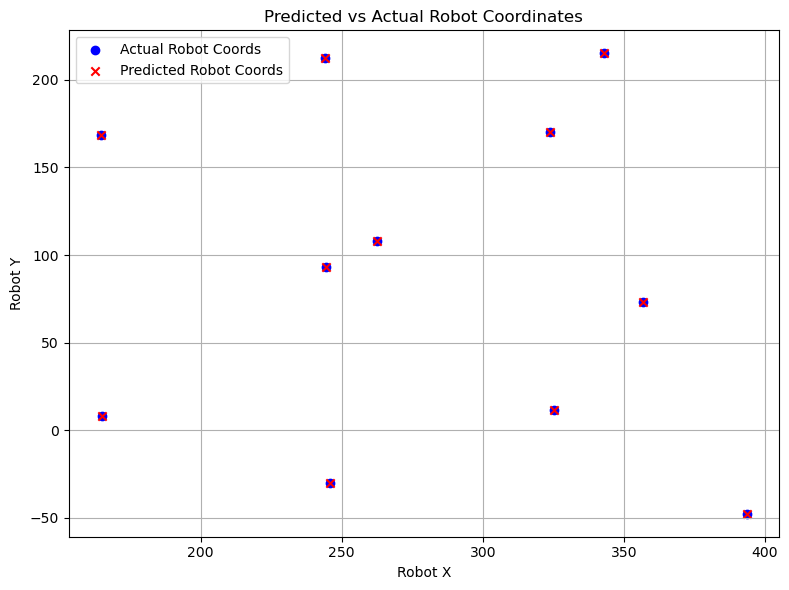

In [22]:
# 🔍 Predict all camera coords
with torch.no_grad():
    predictions = model(X_tensor).numpy()
    predictions_denorm = predictions * robot_std + robot_mean

# 📈 Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(robot_coordinates[:, 0], robot_coordinates[:, 1], label='Actual Robot Coords', color='blue')
plt.scatter(predictions_denorm[:, 0], predictions_denorm[:, 1], label='Predicted Robot Coords', color='red', marker='x')
for i in range(len(robot_coordinates)):
    plt.plot([robot_coordinates[i, 0], predictions_denorm[i, 0]],
             [robot_coordinates[i, 1], predictions_denorm[i, 1]], 'gray', linestyle='dotted')
plt.title("Predicted vs Actual Robot Coordinates")
plt.xlabel("Robot X")
plt.ylabel("Robot Y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Predict sub-routine

In [23]:
def predict_robot_coords(camera_x, camera_y):
    checkpoint = torch.load('camera_to_robot_model.pt', weights_only=False)
    
    model = CoordNet()
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    cam_mean = checkpoint['camera_mean']
    cam_std = checkpoint['camera_std']
    rob_mean = checkpoint['robot_mean']
    rob_std = checkpoint['robot_std']
    
    input_tensor = torch.tensor([(camera_x - cam_mean[0]) / cam_std[0],
                                 (camera_y - cam_mean[1]) / cam_std[1]]).float().unsqueeze(0)
    
    with torch.no_grad():
        pred_norm = model(input_tensor)
        pred_actual = pred_norm * torch.tensor(rob_std) + torch.tensor(rob_mean)
        return pred_actual.numpy().flatten()

## Bring to home

In [24]:
import cv2
import numpy as np
from xarm.wrapper import XArmAPI


arm = XArmAPI('192.168.1.155')
arm.motion_enable(enable=True)
arm.set_mode(0)
arm.set_state(0)
arm.connect()
arm.move_gohome()
arm.set_position(247.13115, -99.8)

ROBOT_IP: 192.168.1.155, VERSION: v2.2.0, PROTOCOL: V1, DETAIL: 6,9,LI1006,DL1000,v2.2.0, TYPE1300: [0, 0]
change protocol identifier to 3


0

## Box coordinates

In [25]:
# Clicked at: (250, 349)
box = predict_robot_coords(427, 128)
box_x, box_y = box

## Pick up sub-routine

In [26]:
import time
def pick_up_and_drop(x_robot, y_robot):
    arm.set_position(x_robot, y_robot, 70, speed=100)  
    arm.set_position(x_robot, y_robot, 18, speed=100, wait=True)  
    arm.set_suction_cup(False)
    time.sleep(1)
    # arm.set_position(x_robot, y_robot, 16.5, wait=True)  
    arm.set_position(x_robot, y_robot, 70, speed=100, wait=True)  
    arm.set_position(box_x, box_y, 200, speed=100)
    arm.set_position(box_x, box_y, 100, speed=100)
    arm.set_suction_cup(True)
    arm.set_position(box_x, box_y, 200, speed=100)

## Capture image

In [27]:
import cv2

cap = cv2.VideoCapture(1)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame. Exiting...")
        break

    cv2.imshow('Webcam Preview - Press Q to capture', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        cv2.imwrite('captured_image.jpg', frame)
        print("Image saved as captured_image.jpg")
        break

cap.release()
cv2.destroyAllWindows()

Image saved as captured_image.jpg


## Vision API

In [28]:
import dotenv
import os
from google import genai
from google.genai import types
from PIL import Image
import io
import os
import requests
from io import BytesIO

dotenv.load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

model_name = "gemini-2.0-flash" 

bounding_box_system_instructions = """
    Return bounding boxes as a JSON array with labels. Never return masks or code fencing. Limit to 25 objects.
    If an object is present multiple times, name them according to their unique characteristic (colors, size, position, unique characteristics, etc..).
    """

client = genai.Client(api_key=GEMINI_API_KEY)

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

## Plot sub-routine

In [29]:
import json
import random
import io
from PIL import Image, ImageDraw, ImageFont
from PIL import ImageColor

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    # Parsing out the markdown fencing
    bounding_boxes = parse_json(bounding_boxes)

    font = ImageFont.load_default()

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(json.loads(bounding_boxes)):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
      abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
      abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
      abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color, font=font)

    # Display the image
    img.save("output_image.jpg")  # or "output_image.png"
    print("Image saved as output_image.jpg")

    img.show()

In [30]:
def parse_json(json_output):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output

In [31]:
prompt = "Detect the 2d bounding boxes of the small cubes (with “label” as color of the small cube) outside the brown box"  # @param {type:"string"}

image = "captured_image.jpg"
# Load and resize image
im = Image.open(io.BytesIO(open(image, "rb").read()))
im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
    )
)

# Check output
print(response.text)

```json
[
  {"box_2d": [21, 275, 100, 327], "label": "green"},
  {"box_2d": [161, 338, 237, 387], "label": "yellow"},
  {"box_2d": [150, 533, 225, 581], "label": "green"},
  {"box_2d": [219, 662, 292, 712], "label": "green"},
  {"box_2d": [274, 481, 356, 526], "label": "green"},
  {"box_2d": [121, 610, 195, 655], "label": "red"},
  {"box_2d": [0, 745, 100, 867], "label": "blue"}
]
```


In [32]:
plot_bounding_boxes(im, response.text)

(640, 480)
Image saved as output_image.jpg


## Pick up routine

In [ ]:
import torch
bounding_boxes = parse_json(response.text)
with open("bounding_box.json", "w") as f:
    f.write(bounding_boxes)
    
for i, bounding_box in enumerate(json.loads(bounding_boxes)):

    width, height = im.size
    # Convert normalized coordinates to absolute coordinates
    abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
    abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
    abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
    abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

    if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

    if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y
    
    centroid1 = (abs_x1 + abs_x2) / 2
    centroid2 = (abs_y1 + abs_y2) / 2

    c1_robot, c2_robot = predict_robot_coords(centroid1, centroid2)
    pick_up_and_drop(c1_robot, c2_robot)
arm.move_gohome()

0

[SDK][ERROR][2025-04-07 18:39:17][base.py:293] - - [main-socket] recv error: [WinError 10054] An existing connection was forcibly closed by the remote host
[SDK][ERROR][2025-04-07 18:39:17][base.py:247] - - [report-socket] recv error: [WinError 10054] An existing connection was forcibly closed by the remote host
